# Exploratory Data Analysis: US Traffic Accident Severity

**Project:** Predicting Traffic Accident Severity  
**Authors:** Osvaldo Rivera, Nitin Nellisserry  

In [15]:
# This section we will begin to explore, clean, and prepare the US Accidents dataset for modeling 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1) Load Data
# ==========================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

df = pd.read_csv("datasets/US_Accidents_March23.csv")
df = df.sample(n=300000, random_state=42)
df.head()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7133276,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,At Haverhill Rd - Earlier accident.,N Haverhill Rd,West Palm Beach,Palm Beach,FL,33417-4638,US,US/Eastern,KPBI,2020-04-17 09:24:00,78.0,78.0,81.0,30.13,10.0,ESE,13.0,0.01,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day
5363845,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,Incident on STANFORD RANCH RD near HOUSE 6750 ...,Stanford Ranch Rd,Roseville,Placer,CA,95678-1907,US,US/Pacific,KMCC,2022-04-21 09:55:00,55.0,55.0,88.0,29.83,10.0,SSE,9.0,0.00,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day
155993,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,Accident on GA-140 Holcomb Bridge Rd Westbound...,Barnwell Rd,Alpharetta,Fulton,GA,30022,US,US/Eastern,KPDK,2016-08-12 16:53:00,91.0,NaN,47.0,29.91,10.0,South,10.4,NaN,Partly Cloudy,False,False,True,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1861414,A-1871277,Source2,3,2019-09-20 15:22:16,2019-09-20 15:56:00,47.118706,-122.556908,NaN,NaN,0.000,Left lane blocked due to accident on I-5 North...,I-5 S,Tacoma,Pierce,WA,98433,US,US/Pacific,KGRF,2019-09-20 14:58:00,67.0,67.0,84.0,29.78,10.0,WNW,3.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2021359,A-2031222,Source2,2,2019-06-03 16:55:43,2019-06-03 18:12:09,33.451355,-111.890343,NaN,NaN,0.000,Right lane closed due to accident on AZ-101-LO...,E McKellips Rd,Scottsdale,Maricopa,AZ,85256,US,US/Mountain,KFFZ,2019-06-03 16:51:00,95.0,95.0,16.0,28.53,10.0,WSW,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day


In [16]:
# ==========================================
# 2) Basic Overview + Missingness
# ==========================================
print(df.shape)
df.info()

missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

(300000, 46)
<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 7133276 to 6130162
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     300000 non-null  object 
 1   Source                 300000 non-null  object 
 2   Severity               300000 non-null  int64  
 3   Start_Time             300000 non-null  object 
 4   End_Time               300000 non-null  object 
 5   Start_Lat              300000 non-null  float64
 6   Start_Lng              300000 non-null  float64
 7   End_Lat                167565 non-null  float64
 8   End_Lng                167565 non-null  float64
 9   Distance(mi)           300000 non-null  float64
 10  Description            299999 non-null  object 
 11  Street                 299549 non-null  object 
 12  City                   299992 non-null  object 
 13  County                 300000 non-null  object 
 14  State                

End_Lng                  0.441450
End_Lat                  0.441450
Precipitation(in)        0.285513
Wind_Chill(F)            0.259103
Wind_Speed(mph)          0.074203
Visibility(mi)           0.022660
Wind_Direction           0.022637
Humidity(%)              0.022407
Weather_Condition        0.022150
Temperature(F)           0.021023
Pressure(in)             0.017987
Weather_Timestamp        0.015420
Sunrise_Sunset           0.003040
Civil_Twilight           0.003040
Astronomical_Twilight    0.003040
Nautical_Twilight        0.003040
Airport_Code             0.002893
Street                   0.001503
Timezone                 0.000963
Zipcode                  0.000207
dtype: float64

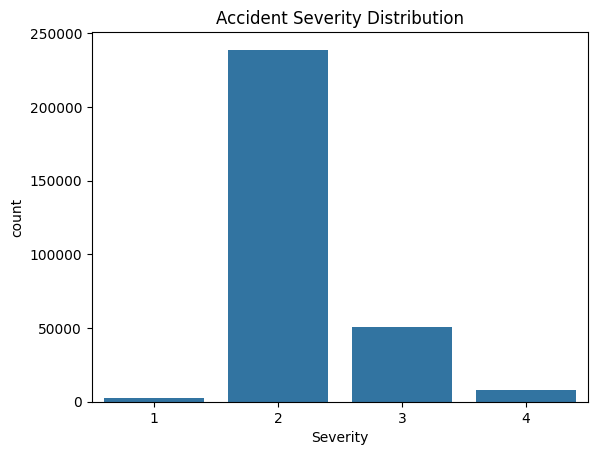

In [17]:
# ==========================================
# 3) Target EDA (Severity Distribution)
# ==========================================
df["Severity"].value_counts(normalize=True)

sns.countplot(x="Severity", data=df)
plt.title("Accident Severity Distribution")
plt.show()

In [18]:
# ==========================================
# 4) Select Relevant Columns (keep it focused)
# ==========================================
selected_cols = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Weather_Condition", "Precipitation(in)",
    "Wind_Speed(mph)", "Traffic_Signal", "Junction", "Crossing",
    "State"
]

df = df[selected_cols].copy()
print("After column selection:", df.shape)
df.head()

After column selection: (300000, 12)


,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,State
7133276,1,2020-04-17 09:29:30,78.0,81.0,10.0,Mostly Cloudy,0.01,13.0,True,False,False,FL
5363845,2,2022-04-21 10:01:00.000000000,55.0,88.0,10.0,Mostly Cloudy,0.00,9.0,False,False,True,CA
155993,3,2016-08-12 16:45:00,91.0,47.0,10.0,Partly Cloudy,NaN,10.4,False,False,True,GA
1861414,3,2019-09-20 15:22:16,67.0,84.0,10.0,Cloudy,0.00,3.0,False,False,False,WA
2021359,2,2019-06-03 16:55:43,95.0,16.0,10.0,Fair,0.00,6.0,False,False,False,AZ


In [19]:
# ==========================================
# 5) Parse Datetime + Feature Engineering
# ==========================================

df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")

# Drop invalid timestamps
before = len(df)
df = df.dropna(subset=["Start_Time"]).copy()
after = len(df)
print(f"Dropped {before-after} rows due to invalid Start_Time ({(before-after)/before:.3%})")

df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df.head()

Dropped 0 rows due to invalid Start_Time (0.000%)


,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,State,Hour,DayOfWeek,Is_Weekend
7133276,1,2020-04-17 09:29:30,78.0,81.0,10.0,Mostly Cloudy,0.01,13.0,True,False,False,FL,9,4,0
5363845,2,2022-04-21 10:01:00,55.0,88.0,10.0,Mostly Cloudy,0.00,9.0,False,False,True,CA,10,3,0
155993,3,2016-08-12 16:45:00,91.0,47.0,10.0,Partly Cloudy,NaN,10.4,False,False,True,GA,16,4,0
1861414,3,2019-09-20 15:22:16,67.0,84.0,10.0,Cloudy,0.00,3.0,False,False,False,WA,15,4,0
2021359,2,2019-06-03 16:55:43,95.0,16.0,10.0,Fair,0.00,6.0,False,False,False,AZ,16,0,0


High_Severity
0    0.80458
1    0.19542
Name: proportion, dtype: float64


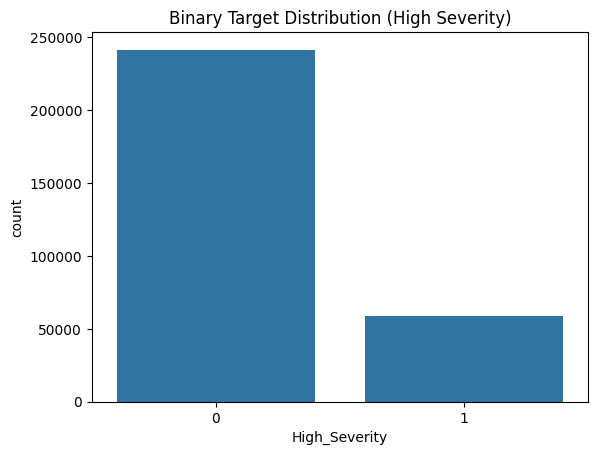

High severity rate: 0.19542
Severity
1    0.008643
2    0.795937
3    0.168667
4    0.026753
Name: proportion, dtype: float64


In [20]:
# ==========================================
# 6) Create Binary Target (High Severity = 3 or 4)
# ==========================================
df["High_Severity"] = (df["Severity"] >= 3).astype(int)
print(df["High_Severity"].value_counts(normalize=True))

sns.countplot(x="High_Severity", data=df)
plt.title("Binary Target Distribution (High Severity)")
plt.show()

# idk if we rlly need this below
print("High severity rate:", df["High_Severity"].mean())
print(df["Severity"].value_counts(normalize=True).sort_index())

In [21]:
# ==========================================
# 7) Handle Missing Values (no inplace)
# ==========================================
df["Temperature(F)"] = df["Temperature(F)"].fillna(df["Temperature(F)"].median())
df["Humidity(%)"] = df["Humidity(%)"].fillna(df["Humidity(%)"].median())
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(df["Visibility(mi)"].median())

# Precipitation: treat missing as 0
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)

df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median())

# Categorical
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

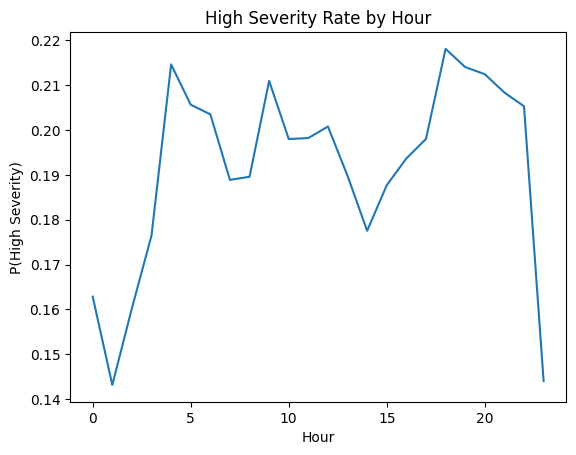

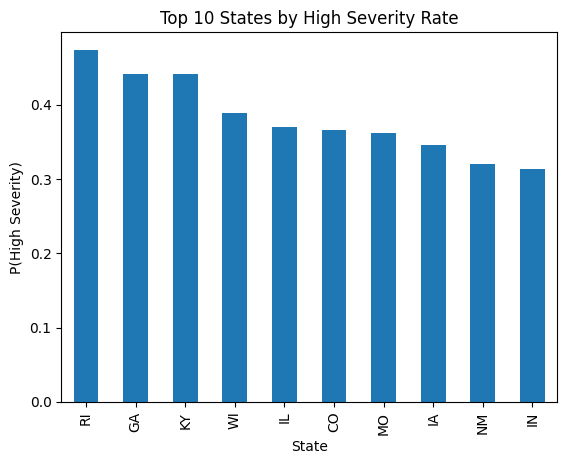

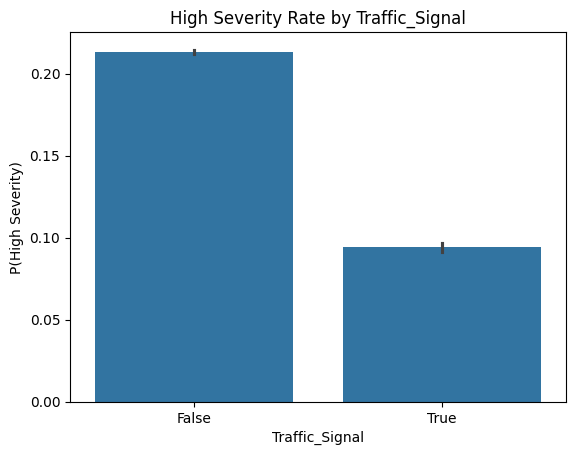

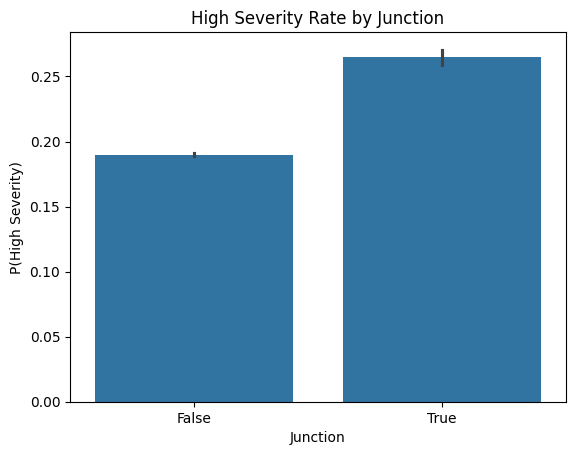

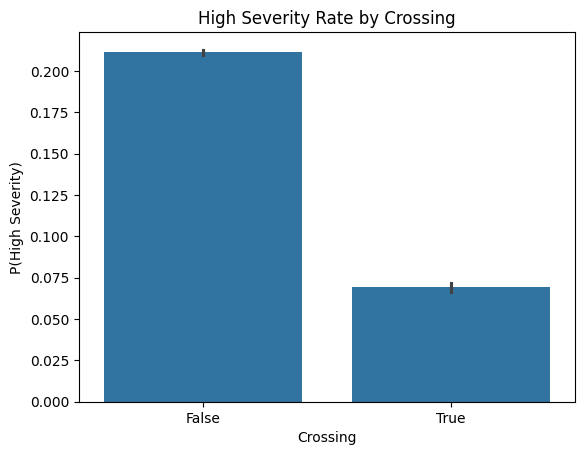

In [22]:
# EDA Visuals
# A) High severity rate by hour
hour_rate = df.groupby("Hour")["High_Severity"].mean()
hour_rate.plot(kind="line")
plt.title("High Severity Rate by Hour")
plt.ylabel("P(High Severity)")
plt.show()

# B) Severity rate by state (top 10)
state_rate = df.groupby("State")["High_Severity"].mean().sort_values(ascending=False).head(10)
state_rate.plot(kind="bar")
plt.title("Top 10 States by High Severity Rate")
plt.ylabel("P(High Severity)")
plt.show()

# C) Infrastructure flags vs severity
for col in ["Traffic_Signal", "Junction", "Crossing"]:
    sns.barplot(x=col, y="High_Severity", data=df)
    plt.title(f"High Severity Rate by {col}")
    plt.ylabel("P(High Severity)")
    plt.show()

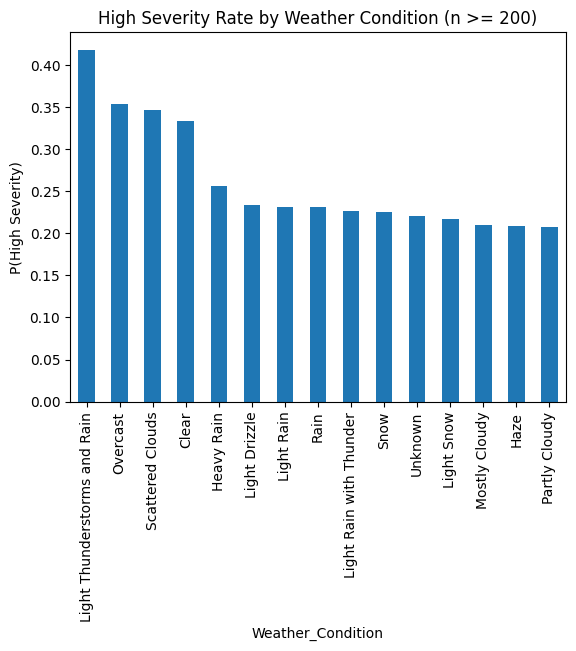

In [23]:
# Weather vs Severity
weather_stats = (
    df.groupby("Weather_Condition")["High_Severity"]
      .agg(rate="mean", n="size")
      .sort_values("rate", ascending=False)
)

# Only show categories with enough samples
weather_stats_filtered = weather_stats[weather_stats["n"] >= 200].head(15)
weather_stats_filtered

weather_stats_filtered["rate"].sort_values(ascending=False).plot(kind="bar")
plt.title("High Severity Rate by Weather Condition (n >= 200)")
plt.ylabel("P(High Severity)")
plt.show()

In [24]:
# ==========================================
# 9) One-Hot Encode Categorical Variables
# ==========================================
df_model = df.drop(columns=["Start_Time"])  # keep engineered time features
df_model = pd.get_dummies(df_model, columns=["Weather_Condition", "State"], drop_first=True)

print("Model-ready shape:", df_model.shape)
df_model.head()

Model-ready shape: (300000, 156)


,Severity,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,Hour,DayOfWeek,Is_Weekend,High_Severity,Weather_Condition_Blowing Dust / Windy,Weather_Condition_Blowing Snow,Weather_Condition_Blowing Snow / Windy,Weather_Condition_Clear,Weather_Condition_Cloudy,Weather_Condition_Cloudy / Windy,Weather_Condition_Drizzle,Weather_Condition_Drizzle / Windy,Weather_Condition_Drizzle and Fog,Weather_Condition_Fair,Weather_Condition_Fair / Windy,Weather_Condition_Fog,Weather_Condition_Fog / Windy,Weather_Condition_Freezing Drizzle,Weather_Condition_Freezing Rain,Weather_Condition_Freezing Rain / Windy,Weather_Condition_Funnel Cloud,Weather_Condition_Hail,Weather_Condition_Haze,Weather_Condition_Haze / Windy,Weather_Condition_Heavy Drizzle,Weather_Condition_Heavy Freezing Drizzle,Weather_Condition_Heavy Rain,Weather_Condition_Heavy Rain / Windy,Weather_Condition_Heavy Sleet,Weather_Condition_Heavy Snow,Weather_Condition_Heavy Snow / Windy,Weather_Condition_Heavy T-Storm,Weather_Condition_Heavy T-Storm / Windy,Weather_Condition_Heavy Thunderstorms and Rain,Weather_Condition_Ice Pellets,Weather_Condition_Light Drizzle,Weather_Condition_Light Drizzle / Windy,Weather_Condition_Light Freezing Drizzle,Weather_Condition_Light Freezing Fog,Weather_Condition_Light Freezing Rain,Weather_Condition_Light Freezing Rain / Windy,Weather_Condition_Light Ice Pellets,Weather_Condition_Light Rain,Weather_Condition_Light Rain / Windy,Weather_Condition_Light Rain Shower,Weather_Condition_Light Rain Showers,Weather_Condition_Light Rain with Thunder,Weather_Condition_Light Sleet,Weather_Condition_Light Sleet / Windy,Weather_Condition_Light Snow,Weather_Condition_Light Snow / Windy,Weather_Condition_Light Snow Grains,Weather_Condition_Light Snow and Sleet,Weather_Condition_Light Snow and Sleet / Windy,Weather_Condition_Light Snow with Thunder,Weather_Condition_Light Thunderstorms and Rain,Weather_Condition_Mist,Weather_Condition_Mostly Cloudy,Weather_Condition_Mostly Cloudy / Windy,Weather_Condition_N/A Precipitation,Weather_Condition_Overcast,Weather_Condition_Partial Fog,Weather_Condition_Partly Cloudy,Weather_Condition_Partly Cloudy / Windy,Weather_Condition_Patches of Fog,Weather_Condition_Rain,Weather_Condition_Rain / Windy,Weather_Condition_Rain Shower,Weather_Condition_Rain Showers,Weather_Condition_Rain and Sleet,Weather_Condition_Sand / Dust Whirlwinds,Weather_Condition_Scattered Clouds,Weather_Condition_Shallow Fog,Weather_Condition_Shallow Fog / Windy,Weather_Condition_Showers in the Vicinity,Weather_Condition_Sleet,Weather_Condition_Small Hail,Weather_Condition_Smoke,Weather_Condition_Smoke / Windy,Weather_Condition_Snow,Weather_Condition_Snow / Windy,Weather_Condition_Snow and Sleet,Weather_Condition_Snow and Sleet / Windy,Weather_Condition_Snow and Thunder,Weather_Condition_Squalls,Weather_Condition_Squalls / Windy,Weather_Condition_T-Storm,Weather_Condition_T-Storm / Windy,Weather_Condition_Thunder,Weather_Condition_Thunder / Windy,Weather_Condition_Thunder in the Vicinity,Weather_Condition_Thunderstorm,Weather_Condition_Thunderstorms and Rain,Weather_Condition_Thunderstorms and Snow,Weather_Condition_Tornado,Weather_Condition_Unknown,Weather_Condition_Widespread Dust,Weather_Condition_Wintry Mix,Weather_Condition_Wintry Mix / Windy,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,State_ME,State_MI,State_MN,State_MO,State_MS,State_MT,State_NC,State_ND,State_NE,State_NH,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
7133276,1,78.0,81.0,10.0,0.01,13.0,True,False,False,9,4,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [25]:
# Save cleaned dataset
df_model.to_csv("datasets/cleaned_accidents.csv", index=False)

# Train Test Split

In [26]:
# ==========================================
# 10) Train/Test Split (IMPORTANT: Prevent Leakage)
# ==========================================
# Prevent leakage: drop BOTH High_Severity (target) AND Severity (used to create target)
X = df_model.drop(columns=["High_Severity", "Severity"])
y = df_model["High_Severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train high severity rate:", y_train.mean(), "Test high severity rate:", y_test.mean())

Train size: (240000, 154) Test size: (60000, 154)
Train high severity rate: 0.19542083333333332 Test high severity rate: 0.19541666666666666


# Modelling

In [27]:
# ==========================================
# 11) Helper: Evaluation Function
# ==========================================
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"\n==== {name} ====")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC-AUC, NOT SURE IF WE WANT THIS
    roc = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC: {roc:.4f}")

    # Return key metrics (focus on class 1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
    return {"Model": name, "Precision": precision, "Recall": recall, "F1": f1, "ROC_AUC": roc}


==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.89      0.68      0.77     48275
           1       0.33      0.66      0.44     11725

    accuracy                           0.68     60000
   macro avg       0.61      0.67      0.61     60000
weighted avg       0.78      0.68      0.71     60000



c:\Users\osval\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


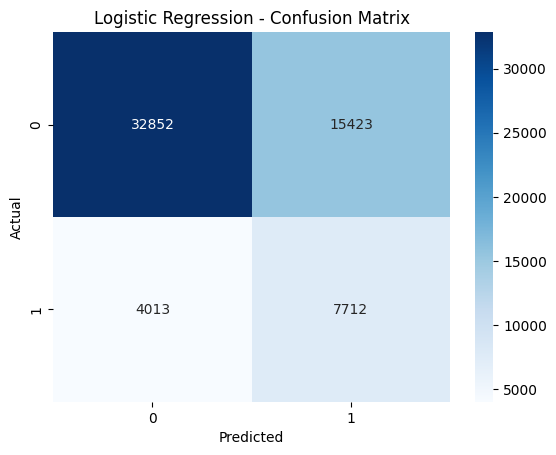

ROC-AUC: 0.7273


{'Model': 'Logistic Regression',
 'Precision': np.float64(0.3333477415171818),
 'Recall': np.float64(0.6577398720682303),
 'F1': np.float64(0.44245553643144003),
 'ROC_AUC': np.float64(0.7273051094310204)}

In [28]:
# ==========================================
# 12) Logistic Regression Baseline
# ==========================================
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train, y_train)

log_metrics = evaluate_model("Logistic Regression", log_model, X_test, y_test)
log_metrics


==== Random Forest ====
              precision    recall  f1-score   support

           0       0.83      0.96      0.89     48275
           1       0.51      0.18      0.27     11725

    accuracy                           0.81     60000
   macro avg       0.67      0.57      0.58     60000
weighted avg       0.77      0.81      0.77     60000



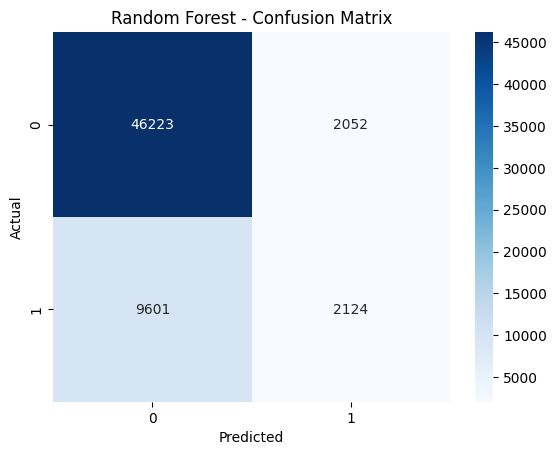

ROC-AUC: 0.7371


{'Model': 'Random Forest',
 'Precision': np.float64(0.5086206896551724),
 'Recall': np.float64(0.18115138592750532),
 'F1': np.float64(0.2671530092447016),
 'ROC_AUC': np.float64(0.7371092808503168)}

In [29]:
# ==========================================
# 13) Random Forest
# ==========================================
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_metrics = evaluate_model("Random Forest", rf, X_test, y_test)
rf_metrics

In [30]:
# ==========================================
# 14) Compare Models (Table)
# ==========================================
results = pd.DataFrame([log_metrics, rf_metrics])
results

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.333348,0.657740,0.442456,0.727305
1,Random Forest,0.508621,0.181151,0.267153,0.737109


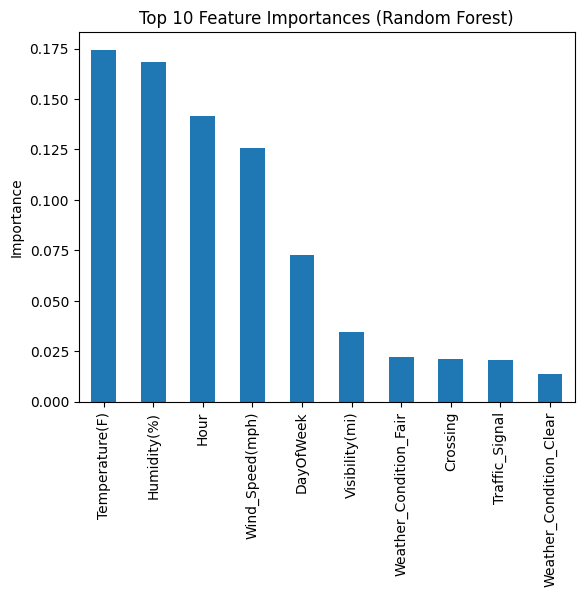

Temperature(F)             0.174387
Humidity(%)                0.168349
Hour                       0.141784
Wind_Speed(mph)            0.125495
DayOfWeek                  0.072532
Visibility(mi)             0.034650
Weather_Condition_Fair     0.022356
Crossing                   0.021356
Traffic_Signal             0.020818
Weather_Condition_Clear    0.013574
dtype: float64

In [31]:
# ==========================================
# 15) Feature Importance (Random Forest)
# ==========================================
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top10 = importances.sort_values(ascending=False).head(10)

top10.plot(kind="bar")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.show()

top10